# GSM State Function 2 - Lightweight Implementation

This notebook demonstrates the `GSMStateFn2` class, a simplified approach to thermodynamic state function representation using symbolic variables organized into natural and conjugate categories.

## Key Features:
- Lightweight design with minimal complexity
- Clear separation of natural vs conjugate variables
- Thermal, mechanical, and internal variable domains
- Simple interface for constitutive relation computation

## Import Required Libraries

Import sympy for symbolic mathematics, typing for type hints, and other necessary modules.

In [ ]:
import sympy as sp
from typing import Optional
import sys
import os

# Add the current directory to Python path for importing our module
sys.path.insert(0, os.getcwd())

# Import our lightweight state function class
from gsm_state_fn import GSMStateFn

# Import customized symbol definitions following naming conventions
from gsm_vars import Scalar

# Enable LaTeX rendering for better display
sp.init_printing(use_latex=True)

## Define Symbolic Variables

Create symbolic variables for our thermodynamic state function demonstration.

In [2]:
# Define Extended Test Model and Initialize GSMThermodynBox
print("Extended Test Model: Elastic-Damage Material with Thermal Capacity")
print("=" * 70)

# Define symbolic variables using customized Scalar class with proper LaTeX symbols and codenames
# Following the naming conventions from VARIABLE_NAMING.md

# Thermal variables (Category 0)
T = Scalar(r'\vartheta', codename='T', real=True, positive=True)  # Temperature (intensive)
S = Scalar('S', codename='S', real=True)                 # Entropy (extensive)

# External mechanical variables (Category 0.1)
eps = Scalar(r'\varepsilon', codename='eps', real=True)  # External strain (extensive)
sig = Scalar(r'\sigma', codename='sig', real=True)       # External stress (intensive)

# Damage variables (Category 2)
omega = Scalar(r'\omega', codename='omega', real=True, positive=True)  # Damage parameter
Y = Scalar('Y', codename='Y', real=True)                               # Damage driving force

# Material parameters
E = Scalar('E', codename='E', positive=True)  # Young's modulus

# Thermal capacity parameters
C_eps = Scalar(r'C_{\varepsilon}', codename='C_eps', real=True, nonnegative=True)  # Thermal capacity
T_0 = Scalar(r'\vartheta_0', codename='T_0', real=True, nonnegative=True)     # Reference temperature

print("Symbolic variables defined with proper LaTeX notation:")
print(f"Temperature:      {T} (codename: {T.codename})")
print(f"Entropy:          {S} (codename: {S.codename})")  
print(f"Strain:           {eps} (codename: {eps.codename})")
print(f"Stress:           {sig} (codename: {sig.codename})")
print(f"Damage:           {omega} (codename: {omega.codename})")
print(f"Damage force:     {Y} (codename: {Y.codename})")
print(f"Young's modulus:  {E} (codename: {E.codename})")
print(f"Thermal capacity: {C_eps} (codename: {C_eps.codename})")
print(f"Reference temp:   {T_0} (codename: {T_0.codename})")


Extended Test Model: Elastic-Damage Material with Thermal Capacity
Symbolic variables defined with proper LaTeX notation:
Temperature:      \vartheta (codename: T)
Entropy:          S (codename: S)
Strain:           \varepsilon (codename: eps)
Stress:           \sigma (codename: sig)
Damage:           \omega (codename: omega)
Damage force:     Y (codename: Y)
Young's modulus:  E (codename: E)
Thermal capacity: C_{\varepsilon} (codename: C_eps)
Reference temp:   \vartheta_0 (codename: T_0)


## Create Class Instance with Example Function

Instantiate the GSMStateFn2 class with a simple thermodynamic function expression - a Helmholtz free energy for a damaged elastic material.

Helmholtz Free Energy Expression:


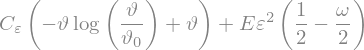


GSMStateFn2 instance created successfully!
GSMStateFn2(f(\vartheta, \varepsilon, \omega) = C_{\varepsilon}*(-\vartheta*log(\vartheta/\vartheta_0) + \vartheta) + E*\varepsilon**2*(1/2 - \omega/2))


In [3]:
# Define a Helmholtz free energy expression: F(T, ε, Ɛ)
# Simple damaged elastic energy with temperature dependence

# Extended Helmholtz free energy: elastic-damage + thermal capacity
F_elastic = sp.Rational(1, 2) * (1 - omega) * E * eps**2
F_thermal = C_eps * (T - T * sp.log(T / T_0))
F_expr = F_elastic + F_thermal

print("Helmholtz Free Energy Expression:")
display(F_expr)
print()

# Create GSMStateFn2 instance for Helmholtz free energy F(T, ε, Ɛ)
# Natural variables: T (thermal), eps (mechanical), Eps (internal)
# Conjugate variables: S (thermal), sig (mechanical), Sig (internal)
helmholtz_fn = GSMStateFn(
    fn_expr=F_expr,
    th_x_var=T,
    th_y_var=S,
    mc_x_var=eps,       # Strain is natural for Helmholtz (single symbol)
    mc_y_var=sig,       # Stress is conjugate (single symbol)
    Eps_var=(omega,),   # Internal variables can still be tuples
    Sig_var=(Y,),       # Internal variables can still be tuples
)

print("GSMStateFn2 instance created successfully!")
print(helmholtz_fn)

## Display Function Expression

Render and display the mathematical expression of the thermodynamic function using sympy's display capabilities.

State Function Overview:
GSM State Function Overview
Expression: C_{\varepsilon}*(-\vartheta*log(\vartheta/\vartheta_0) + \vartheta) + E*\varepsilon**2*(1/2 - \omega/2)

Natural Variables (independent):
  Thermal: \vartheta
  Mechanical: \varepsilon
  Internal: (\omega,)

Conjugate Variables (derivatives):
  Thermal: S
  Mechanical: \sigma
  Internal: (Y,)


Mathematical Expression (LaTeX rendering):


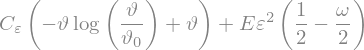


Function signature: F(\vartheta, \varepsilon, \omega)


In [4]:
print("State Function Overview:")
helmholtz_fn.print_overview()

print("\nMathematical Expression (LaTeX rendering):")
display(helmholtz_fn.fn_expr)

print(f"\nFunction signature: F({', '.join(str(var) for var in helmholtz_fn.get_natural_variables())})")

## Review Available Variables

List and display all available thermodynamic variables (both natural and conjugate) with their symbolic representations.

In [5]:
print("Variable Organization:")
print("=" * 40)

print("\nNatural Variables (independent):")
natural_vars = helmholtz_fn.get_natural_variables()
for i, var in enumerate(natural_vars, 1):
    print(f"  {i}. {var}")

print("\nConjugate Variables (derivatives):")
conjugate_vars = helmholtz_fn.get_conjugate_variables()
for i, var in enumerate(conjugate_vars, 1):
    print(f"  {i}. {var}")

print(f"\nTotal variables: {len(helmholtz_fn.get_all_variables())}")

print("\nVariable Details:")
print(f"  Thermal natural: {helmholtz_fn.th_x_var}")
print(f"  Thermal conjugate: {helmholtz_fn.th_y_var}")
print(f"  Mechanical natural: {helmholtz_fn.mc_x_var}")
print(f"  Mechanical conjugate: {helmholtz_fn.mc_y_var}")
print(f"  Internal natural: {helmholtz_fn.Eps_var}")
print(f"  Internal conjugate: {helmholtz_fn.Sig_var}")

Variable Organization:

Natural Variables (independent):
  1. \vartheta
  2. \varepsilon
  3. \omega

Conjugate Variables (derivatives):
  1. S
  2. \sigma
  3. Y

Total variables: 6

Variable Details:
  Thermal natural: \vartheta
  Thermal conjugate: S
  Mechanical natural: \varepsilon
  Mechanical conjugate: \sigma
  Internal natural: (\omega,)
  Internal conjugate: (Y,)


## Test Variable Access

Demonstrate accessing individual variables from the class instance and verify their properties and types.

In [6]:
print("Variable Access Testing:")
print("=" * 30)

# Test individual variable access
print("Thermal Variables:")
print(f"  Natural (th_x_var): {helmholtz_fn.th_x_var} (type: {type(helmholtz_fn.th_x_var)})")
print(f"  Conjugate (th_y_var): {helmholtz_fn.th_y_var} (type: {type(helmholtz_fn.th_y_var)})")

print("\nMechanical Variables:")
print(f"  Natural (mc_x_var): {helmholtz_fn.mc_x_var} (type: {type(helmholtz_fn.mc_x_var)})")
print(f"  Conjugate (mc_y_var): {helmholtz_fn.mc_y_var} (type: {type(helmholtz_fn.mc_y_var)})")

print("\nInternal Variables:")
print(f"  Natural (Eps_var): {helmholtz_fn.Eps_var} (type: {type(helmholtz_fn.Eps_var)})")
print(f"  Conjugate (Sig_var): {helmholtz_fn.Sig_var} (type: {type(helmholtz_fn.Sig_var)})")

# Verify variables are sympy symbols
print(f"\nVerification - All variables are sympy.Symbol:")
all_vars = helmholtz_fn.get_all_variables()
for var in all_vars:
    print(f"  {var}: {isinstance(var, sp.Symbol)}")

Variable Access Testing:
Thermal Variables:
  Natural (th_x_var): \vartheta (type: <class 'gsm_vars.Scalar'>)
  Conjugate (th_y_var): S (type: <class 'gsm_vars.Scalar'>)

Mechanical Variables:
  Natural (mc_x_var): \varepsilon (type: <class 'gsm_vars.Scalar'>)
  Conjugate (mc_y_var): \sigma (type: <class 'gsm_vars.Scalar'>)

Internal Variables:
  Natural (Eps_var): (\omega,) (type: <class 'tuple'>)
  Conjugate (Sig_var): (Y,) (type: <class 'tuple'>)

Verification - All variables are sympy.Symbol:
  \vartheta: True
  \varepsilon: True
  \omega: True
  S: True
  \sigma: True
  Y: True


## Compute Constitutive Relations

Demonstrate the computation of constitutive relations through partial derivatives.

In [7]:
print("Constitutive Relations:")
helmholtz_fn.print_constitutive_relations()

# Get the relations as a dictionary for further analysis
relations = helmholtz_fn.compute_constitutive_relations()

print("Relations Dictionary:")
for conjugate_var, derivative in relations.items():
    print(f"  {conjugate_var} → {derivative}")
    
print(f"\nNumber of constitutive relations: {len(relations)}")

Constitutive Relations:
Constitutive Relations:
S = ∂f/∂\vartheta
     = -C_{\varepsilon}*log(\vartheta/\vartheta_0)

\sigma = ∂f/∂\varepsilon
     = 2*E*\varepsilon*(1/2 - \omega/2)

Y = ∂f/∂\omega
     = -E*\varepsilon**2/2

Relations Dictionary:
  S → -C_{\varepsilon}*log(\vartheta/\vartheta_0)
  \sigma → 2*E*\varepsilon*(1/2 - \omega/2)
  Y → -E*\varepsilon**2/2

Number of constitutive relations: 3


In [8]:
# Test the simplified interface - verify mechanical variables are single symbols
print("Testing simplified interface:")
print(f"Mechanical natural variable type: {type(helmholtz_fn.mc_x_var)}")
print(f"Mechanical conjugate variable type: {type(helmholtz_fn.mc_y_var)}")
print(f"Mechanical natural variable: {helmholtz_fn.mc_x_var}")
print(f"Mechanical conjugate variable: {helmholtz_fn.mc_y_var}")

print(f"\nAll natural variables: {helmholtz_fn.get_natural_variables()}")
print(f"All conjugate variables: {helmholtz_fn.get_conjugate_variables()}")

# Test mechanical constitutive relations
mech_relations = helmholtz_fn.get_mechanical_constitutive_relations()
print(f"\nMechanical constitutive relations: {mech_relations}")
print(f"Number of mechanical relations: {len(mech_relations)}")

Testing simplified interface:
Mechanical natural variable type: <class 'gsm_vars.Scalar'>
Mechanical conjugate variable type: <class 'gsm_vars.Scalar'>
Mechanical natural variable: \varepsilon
Mechanical conjugate variable: \sigma

All natural variables: [\vartheta, \varepsilon, \omega]
All conjugate variables: [S, \sigma, Y]

Mechanical constitutive relations: [(\sigma, 2*E*\varepsilon*(1/2 - \omega/2))]
Number of mechanical relations: 1


In [ ]:
# Test GSMThermodynBox2 with simplified interface
from bmcs_matmod.gsm_lagrange.core2.gsm_thermodyn_box import GSMThermodynBox, StateFunction

print("Testing GSMThermodynBox2 with simplified interface:")
print("=" * 50)

# Create thermodynamic box
thermo_box = GSMThermodynBox(
    initial_state_fn=StateFunction.HELMHOLTZ,
    initial_state_instance=helmholtz_fn,
    T_var=T,
    S_var=S
)

print(f"Box created: {thermo_box}")
print(f"Available functions: {[sf.value for sf in thermo_box.get_available_state_functions()]}")

# Test Legendre transformation
print("\nPerforming Legendre transformation: F → G")
gibbs_fn = thermo_box.legendre_transform(StateFunction.GIBBS)
print(f"Gibbs function created: {gibbs_fn}")
print(f"Gibbs expression: {gibbs_fn.fn_expr}")

# Verify mechanical variables are single symbols
print(f"\nGibbs mechanical variables:")
print(f"  Natural (mc_x): {gibbs_fn.mc_x_var} (type: {type(gibbs_fn.mc_x_var)})")
print(f"  Conjugate (mc_y): {gibbs_fn.mc_y_var} (type: {type(gibbs_fn.mc_y_var)})")

print("\nSimplified interface working correctly!")

Testing GSMThermodynBox2 with simplified interface:
Box created: GSMThermodynBox2(current=F, available=['F'])
Available functions: ['F']

Performing Legendre transformation: F → G
Gibbs function created: GSMStateFn2(f(\vartheta, \sigma, \omega) = C_{\varepsilon}*(-\vartheta*log(\vartheta/\vartheta_0) + \vartheta) + E*\varepsilon**2*(1/2 - \omega/2) - \sigma*\varepsilon)
Gibbs expression: C_{\varepsilon}*(-\vartheta*log(\vartheta/\vartheta_0) + \vartheta) + E*\varepsilon**2*(1/2 - \omega/2) - \sigma*\varepsilon

Gibbs mechanical variables:
  Natural (mc_x): \sigma (type: <class 'gsm_vars.Scalar'>)
  Conjugate (mc_y): \varepsilon (type: <class 'gsm_vars.Scalar'>)

Simplified interface working correctly!
